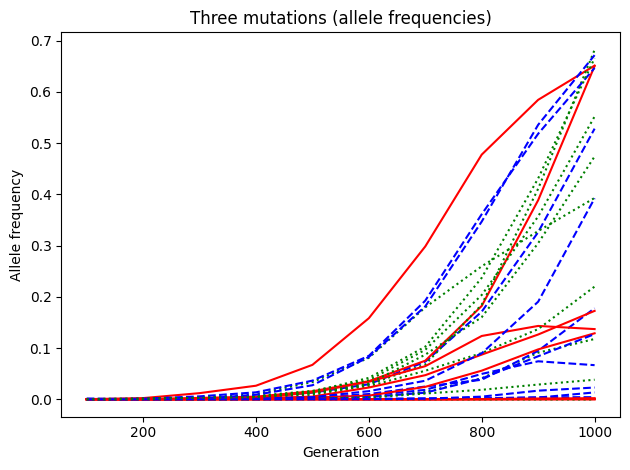

In [1]:
from sbi.diagnostics.lc2st import LC2ST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import math
import pickle
import sbi.utils as utils
import torch
from seaborn import histplot, kdeplot, boxplot, violinplot
from time import time
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import wrapper
from evo_sim import evo_sim, EVO_SIM_wrapper, plot_vec30
from inference_utils import get_prior
import warnings
warnings.simplefilter('ignore', FutureWarning)


def EVO_SIM_wrapper(reps, parameters, seed=None):
    evo_reps = torch.empty(reps, 30)
    for i in range(reps):
        out=evo_sim(parameters)
        evo_reps[i,:] = torch.tensor(out)
    return evo_reps

# for making larger graphs
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

posterior = pickle.load(open('posterior_EVO_SIM_30000_20.pkl', 'rb'))
prior = get_prior('EVO_SIM')
pm = prior.mean
x_o = EVO_SIM_wrapper(10, pm)

fig, ax = plt.subplots()
for x in x_o:
    plot_vec30(x, ax=ax)

Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

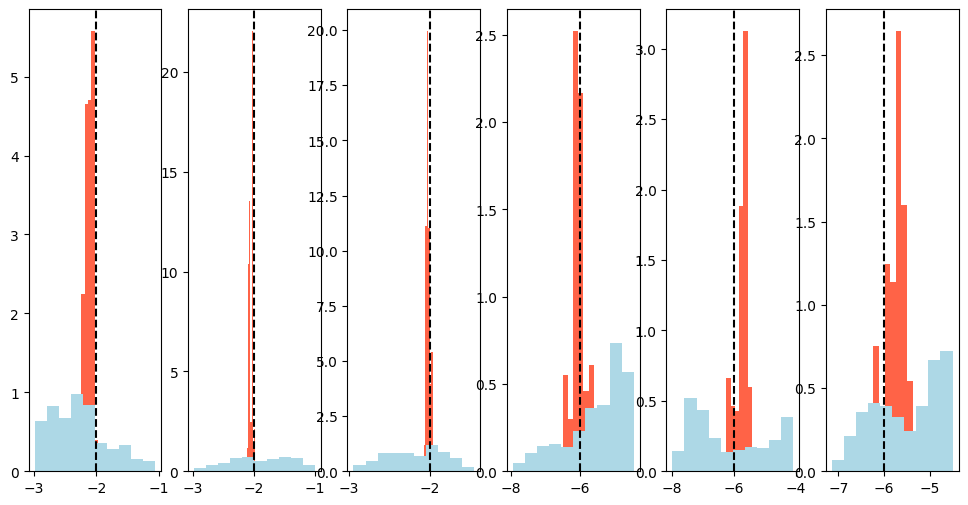

In [14]:

cp = CollectivePosterior(prior, amortized_posterior=posterior, log_C=1, Xs=x_o, epsilon=-5)
# cp.get_log_C()

samples_cp = cp.sample_via_importance(n_final=10000)[0]
# samples_cp = cp.sample(500)

posterior_iid = pickle.load(open('posterior_iid.pkl', 'rb'))
samples_iid = posterior_iid.set_default_x(x_o).sample((500,))

# histograms in 6 axes
fig, ax = plt.subplots(1, 6, figsize=(12, 6))
for i in range(6):
    ax[i].hist(samples_cp[:,i].numpy(), bins=10, density=True, color='tomato')
    ax[i].hist(samples_iid[:,i].numpy(), bins=10, density=True, color='lightblue')
    ax[i].axvline(pm.numpy()[i], color='k', linestyle='--')

In [38]:
test_n = 5
theta = prior.sample((test_n,))
X = torch.cat([EVO_SIM_wrapper(10, t).unsqueeze(0) for t in theta])
n_sample = 500
samples_cp = torch.empty((test_n, n_sample, theta.shape[1]))
samples_iid = torch.empty((test_n, n_sample, theta.shape[1]))
for i, x in enumerate(X):
    cp = CollectivePosterior(prior, amortized_posterior=posterior, log_C=1, Xs=x, epsilon=-10)
    cp.get_log_C()
    samples_cp[i] = cp.sample(n_sample)
    samples_iid[i] = posterior_iid.set_default_x(x).sample((n_sample,))


MCMC from top 50 candidates: 100%|██████████| 500/500 [00:05<00:00, 86.35it/s]


Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

MCMC from top 50 candidates: 100%|██████████| 500/500 [00:05<00:00, 85.43it/s]


Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

MCMC from top 50 candidates: 100%|██████████| 500/500 [00:05<00:00, 86.58it/s]


Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

MCMC from top 50 candidates: 100%|██████████| 500/500 [00:05<00:00, 86.71it/s]


Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

MCMC from top 50 candidates: 100%|██████████| 500/500 [00:05<00:00, 86.79it/s]


Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

In [51]:
samples_cp.shape, X[:,0].shape, theta.shape

(torch.Size([5, 500, 6]), torch.Size([5, 30]), torch.Size([5, 6]))

In [53]:
lc2st_cp = LC2ST(samples_cp, X[:,0], theta)
lc2st_cp.train_under_null_hypothesis()

Training the classifiers under H0, permutation = True:   0%|          | 0/100 [00:00<?, ?it/s]


RuntimeError: Tensors must have same number of dimensions: got 3 and 2